# Introduction to Scikit-Learn's Mathematical Transformers

Before applying mathematical equations to features, we must choose the right transformation framework in `scikit-learn`. The library provides three core transformer classes inside the `sklearn.preprocessing` module. Each operates on a fundamentally different algorithmic mechanism to modify data distributions.

#### The Three Core Transformers:

*   **1. `FunctionTransformer` (Stateless Mapping)**

    *   **Mechanism:** Applies a fixed, user-defined mathematical function (such as `np.log`, `np.sqrt`, or `1/x`) directly to the data.

    *   **Key Characteristic:** It is completely stateless. It does not calculate or store any metrics from the training dataset. It applies the exact same raw formula to training, testing, and production data alike.

    *   **Best Used For:** Simple, predictable, and domain-specific corrections (e.g., converting exponential growth curves into linear trends using logarithms).

*   **2. `PowerTransformer` (Parametric Optimization)**

    *   **Mechanism:** Automatically searches for and calculates an optimal exponent parameter lambda
                       using Maximum Likelihood Estimation (MLE) to minimize data skewness.

    *   **Key Characteristic:** It is stateful. During the `.fit()` stage, it analyzes the distribution variance to learn the best exponent, then applies that specific exponent during the `.transform()` stage. It supports the **Box-Cox** and **Yeo-Johnson** algorithms.

    *   **Best Used For:** Complex skewness where we want the model to dynamically figure out the best stabilizing power transformation.

*   **3. `QuantileTransformer` (Non-Parametric Rank Mapping)**

    *   **Mechanism:** Maps the original cumulative distribution function (CDF) of the features onto a target probability distribution (either a flat **Uniform** or a bell-shaped **Normal** distribution) based purely on data rankings.

    *   **Key Characteristic:** Highly aggressive and stateful. It breaks strict linear distance relationships between values because it focuses entirely on percentiles. It forces even the most chaotic, multi-modal distributions into a clean target shape.

    *   **Best Used For:** Data with heavy tails, unpredictable multi-modal peaks, or extreme outliers that power functions fail to tame.


## The Mechanics of FunctionTransformer

The `FunctionTransformer` (`sklearn.preprocessing.FunctionTransformer`) is the standard tool for executing static mathematical transformations within machine learning pipelines. Because it is stateless, calling `.fit()` does nothing but return the object itself, while `.transform()` applies your chosen function element-wise.

#### Common Syntax Structure:


```python
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# Define a baseline transformer using a NumPy function
transformer = FunctionTransformer(func=np.log1p, validate=True)

# Apply the mathematical transformation to the feature matrix X
X_transformed = transformer.transform(X)
```

---

### The Core Manual Mathematical Transformations:

#### A. Log Transformation (`np.log` and `np.log1p`)
The log transformation calculates the exponent to which the natural base \(e\) must be raised to yield the feature value.

*   **Mathematical Formula:** 
    $y = \ln(x)$
    *Safe Variant:* $y = \ln(x + 1)$

*   **Scikit-Learn Implementation:**
    ```python
    log_transformer = FunctionTransformer(func=np.log1p, validate=True)
    ```

*   **Domain Restrictions:** $(x > 0)$ for `np.log`. For `np.log1p`, $(x \geq 0)$. Negative values yield mathematical errors.

*   **Mechanism:** It pulls extreme right-side outliers closer to the mean while stretching out smaller values clustered near zero. It effectively stabilizes variance when the standard deviation grows proportionally with the mean.

#### B. Reciprocal Transformation (`np.reciprocal`)
The reciprocal transformation divides 1 by the feature value, inversely remapping the scale of the feature.

*   **Mathematical Formula:** 
    $y = \frac{1}{x}$

*   **Scikit-Learn Implementation:**
    ```python
    # Lambda prevents division-by-zero crashes by adding a micro-epsilon if needed
    reciprocal_transformer = FunctionTransformer(func=lambda x: 1.0 / (x + 1e-9), validate=True)
    ```
*   **Domain Restrictions:** $(x \neq 0)$ If the feature contains zero values, the operation approaches infinity $(\infty)$ and crashes the machine learning model.

*   **Mechanism:** It reverses the order of magnitudes (massive values become tiny fractions near zero, and tiny fractions become large numbers). It severely compresses extreme right-side tails.

#### C. Square Root Transformation (`np.sqrt`)
The square root transformation calculates the side length of a square given the feature value as the area.

*   **Mathematical Formula:** 
    $y = \sqrt{x}$
    
*   **Scikit-Learn Implementation:**
    ```python
    sqrt_transformer = FunctionTransformer(func=np.sqrt, validate=True)
    ```
*   **Domain Restrictions:** $x \geq 0$. Negative inputs generate complex numbers, causing runtime errors.
*   **Mechanism:** It behaves like a milder, less aggressive version of the log transformation. It reduces right skewness but does not compress extreme values as heavily as logarithmic functions do.


## The Triad of Skewness Identification

To identify skewness in your data, you should combine all three diagnostics tools: **`df.skew()` gives you the exact numerical score**, **`sns.displot()` lets you visually inspect the shape**, and a **Q-Q plot evaluates how well the data conforms to normality**. 

Using them together prevents us from misinterpreting a visual graph due to binning choices or a single summary statistic masked by outliers.

### **1. Numerical Identification: `pd.DataFrame.skew()`**

Before plotting, calculate the mathematical skewness coefficient using Pandas. This represents the adjusted Fisher-Pearson standardized moment coefficient, calculating the asymmetry of the data distribution around its mean.

#### Mathematical Interpretation Metrics:
*   **Score = 0:** Perfect symmetry (theoretical Gaussian bell curve).
*   **Score > 0 (Positive Skew):** **Right-skewed data**. The tail extends further to the right. The mathematical mean is greater than the median.
*   **Score < 0 (Negative Skew):** **Left-skewed data**. The tail extends further to the left. The mathematical mean is less than the median.

#### Severity Thresholds (Rule of Thumb):
*   **Between -0.5 and 0.5:** Fairly symmetrical distribution. Transformation is rarely required.
*   **Between -1.0 and -0.5 OR 0.5 and 1.0:** Moderately skewed distribution.
*   **Beyond -1.0 or 1.0:** **Highly skewed distribution**. These features are the primary candidates for mathematical transformations.


### **2. Visual & Normality Verification: Density Plots and Q-Q Plots**

#### A. Visual Density Diagnostics via `sns.displot(kde=True)`
A histogram smoothed out with a Kernel Density Estimate (KDE) line provides the most intuitive visual diagnostic of your data's empirical profile.

*   **Right Skew Diagnostics:** The mass of the distribution is concentrated on the left side of the graph, and a long tail drifts off toward the high positive values on the right.
*   **Left Skew Diagnostics:** The mass is clustered on the right side, with a tail dragging out toward the lower or negative values on the left.



#### B. Quantile-Quantile (Q-Q) Plot Verification
A Q-Q plot graphs the empirical quantiles of your actual sample data directly against the theoretical quantiles of a perfect normal distribution.


*   **Perfect Normality:** All sample data points lie precisely along the straight, diagonal 45-degree reference line.
*   **Right Skew Curve:** The data points curve upwards **above** the reference line at the right end (upward bend), indicating that your sample has heavier right-side tails than a normal distribution.
*   **Left Skew Curve:** The points curve **below** the reference line on the left end, showing an elongated left tail.


### **3. Operational Best-Practice Workflow**

When preparing continuous features for parametric machine learning pipelines, follow this structured execution sequence:

1.  **Automated Screening:** Run `df.skew()` across the entire DataFrame to generate a quick, automated list of features where the absolute value is greater than a critical threshold (typically `|0.75|` or `|1.0|`).

2.  **Visual Validation:** Generate `sns.displot()` and `stats.probplot()` side-by-side for the flagged features. This isolates whether the skewness score is caused by a few isolated, extreme outliers or a systematically stretched distribution.

3.  **Transformer Selection Strategy:** 

    *   Use **`FunctionTransformer`** (e.g., `np.log1p` or `np.sqrt`) if the skew follows a smooth, predictable mathematical trend (exponential or counts).

    *   Use **`PowerTransformer(method='yeo-johnson')`** if it is a complex, smooth power skew requiring an auto-tuned variance-stabilizing parameter (\(\lambda\)).

    *   Use **`QuantileTransformer`** if the Q-Q plot shows highly chaotic, multi-modal peaks or heavy tails that power functions cannot smooth.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
import scipy.stats as stats ## QQ plot
from scipy.stats import skew

# Metric
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Mathematical Transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
# Importing DataSet
df = pd.read_csv("../data/titanic.csv", usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [55]:
# Check Missing values
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [54]:
# Fill Missing values 
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [56]:
# Split the dataset into features and target variable

X = df.iloc[:,1:3]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
print(f"Shape of X_Train Set : {X_train.shape}")
print(f"Shape of X_Test Set : {X_test.shape}")

Shape of X_Train Set : (712, 2)
Shape of X_Test Set : (179, 2)


In [20]:
# Function to compare PDF and QQ plot of a feature
def compare_plots(X_train ,feature):
    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)
    sns.histplot(X_train[feature], kde=True)
    plt.title(f'{feature} PDF')

    plt.subplot(122)
    stats.probplot(X_train[feature], dist='norm', plot=plt)
    plt.title(f"{feature} QQ Plot")

    plt.tight_layout()
    plt.show()

# Function to compare QQ plot before and after transformation
def QQ_Plot(X_train, X_train_transformed, feature):
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    stats.probplot(X_train[feature], dist='norm', plot=plt)
    plt.title(f"Before Transformation '{feature}' QQ Plot | Skewness : {skew(X_train[feature])}")
    
    plt.subplot(122)
    stats.probplot(X_train_transformed[feature], dist='norm', plot=plt)
    plt.title(f"After Transformation '{feature}' QQ Plot | Skewness : {skew(X_train_transformed[feature])}")
    
    plt.tight_layout()
    plt.show()
    

# Function to calculate skewness of a feature
def calculate_skewness(series):
    # Remove NaN values
    data = series.dropna()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=0)  # Population std (or use ddof=1 for sample)
    
    # Third central moment / standard deviation cubed
    skewness = np.sum((data - mean) ** 3) / (n * std ** 3)
    return skewness



## 1. Skewness Analysis for given features

#### 1.1 Age Feature Skewness Analysis

Skewness :  0.46272893904780404


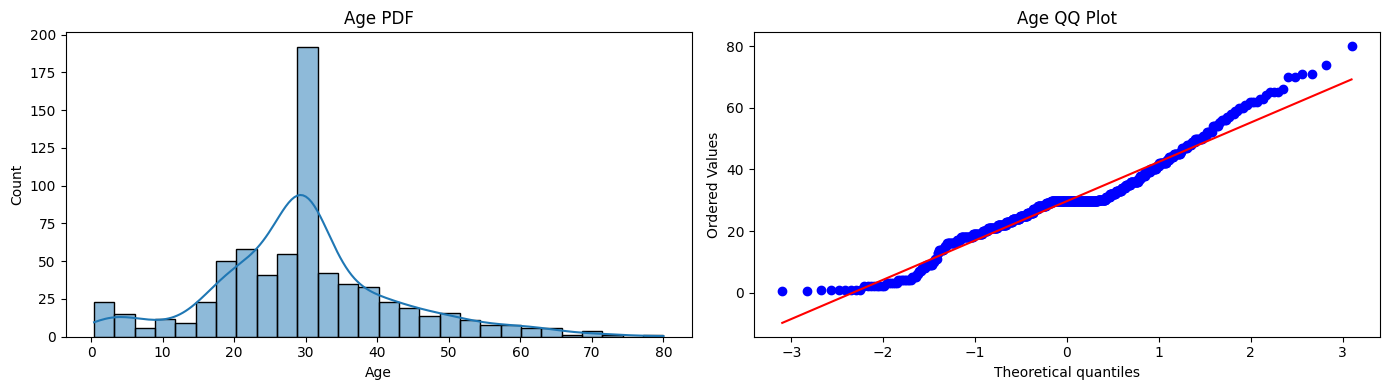

In [ ]:
skewness_age = calculate_skewness(X_train['Age'])
print("Skewness : ",skewness_age)
compare_plots(X_train, 'Age')    

#### 1.2 Fare Feature Skewness Analysis

Skewness :  4.631525563499806


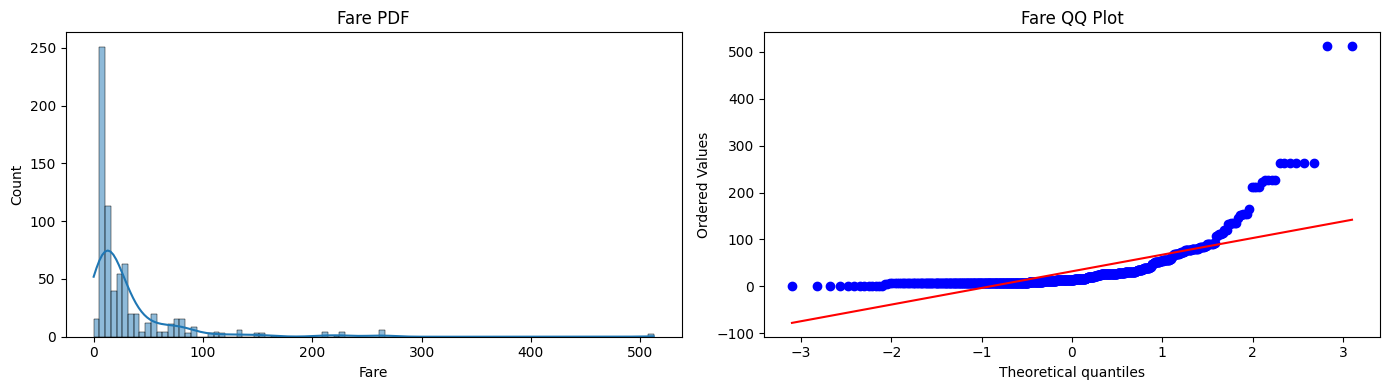

In [22]:
skewness_fare = calculate_skewness(X_train['Fare'])
print("Skewness : ",skewness_fare)
compare_plots(X_train, 'Fare')   

## 2. Model Evaluation Without Transformation


### 2.1 Model Evaluation With Transformation

In [57]:
# Function to train and evaluate models
def Models(X_train, X_test, y_train, y_test):
    
    # Train Logistic Regression and Decision Tree Classifier
    clf1 = LogisticRegression()
    clf2 = DecisionTreeClassifier()

    clf1.fit(X_train, y_train)
    clf2.fit(X_train, y_train)

    y_pred1 = clf1.predict(X_test)
    y_pred2 = clf2.predict(X_test)
    
    accuracy_lr = accuracy_score(y_test, y_pred1)
    accuracy_dt = accuracy_score(y_test, y_pred2)
    
    X_transformed = pd.concat([X_train, X_test])
    y_transformed = pd.concat([y_train, y_test])
    
    cross_val_lr = np.mean(cross_val_score(clf1, X_transformed, y_transformed,scoring='accuracy', cv=10))
    cross_val_dt = np.mean(cross_val_score(clf2, X_transformed, y_transformed, scoring='accuracy', cv=10))
    
    return accuracy_lr, accuracy_dt, cross_val_lr, cross_val_dt

In [58]:
accuracy_lr, accuracy_dt, cross_val_lr, cross_val_dt = Models(X_train, X_test, y_train ,y_test)

print('Logistic Regression Accuracy: ', accuracy_lr, " | Cross val score : ", cross_val_lr)
print('Decision Tree Accuracy: ', accuracy_dt, " | Cross val score : ", cross_val_dt)

Logistic Regression Accuracy:  0.6424581005586593  | Cross val score :  0.6554931335830212
Decision Tree Accuracy:  0.6312849162011173  | Cross val score :  0.6543570536828963


## 3. Model Evaluation With Transformation

In [59]:
# Apply Log Transformation
trf = FunctionTransformer(func=np.log1p) # np.log1p handles zeros

X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.fit_transform(X_test)


#### 3.1 Age Feature Skewness Analysis after Transformation

Skewness :  -2.160102754846165


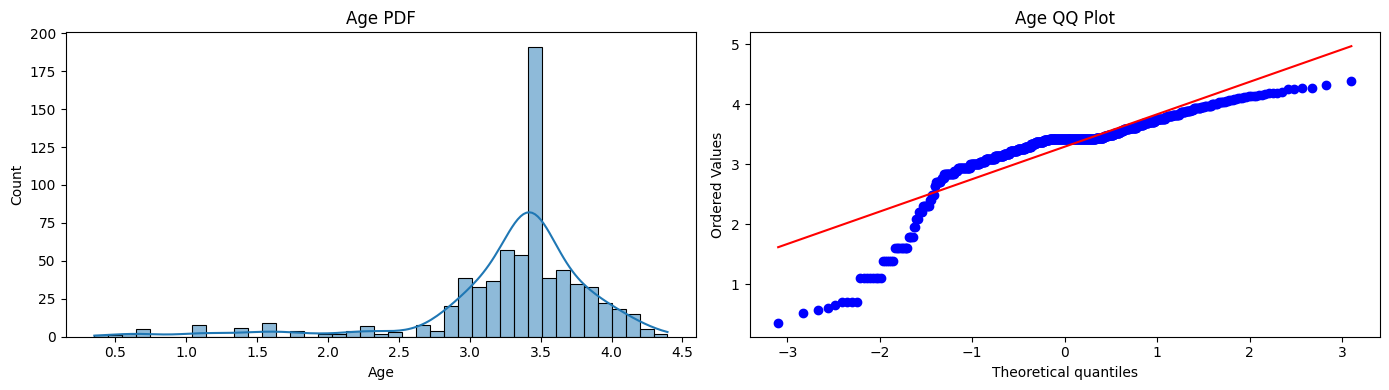

In [26]:
skewness_age = calculate_skewness(X_train_trans['Age'])
print("Skewness : ",skewness_age)
compare_plots(X_train_trans, 'Age')


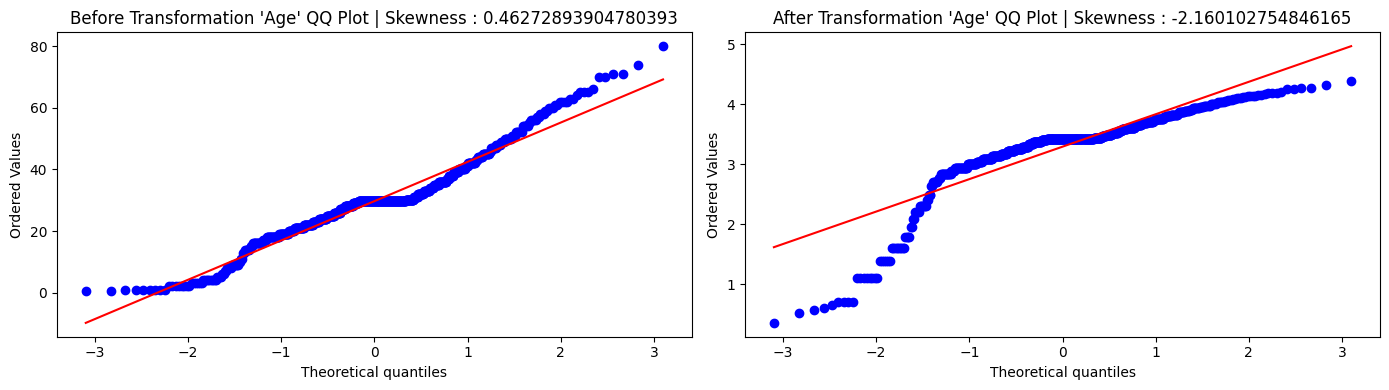

In [27]:
QQ_Plot(X_train, X_train_trans, 'Age')

#### 3.2 Fare Feature Skewness Analysis after Transformation

Skewness :  0.3408274164872958


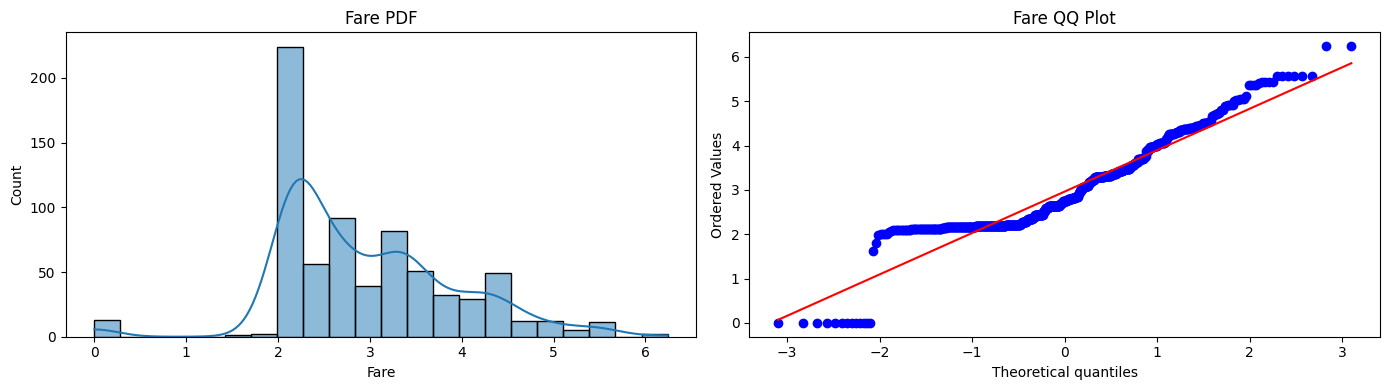

In [28]:
skewness_fare = calculate_skewness(X_train_trans['Fare'])
print("Skewness : ",skewness_fare)
compare_plots(X_train_trans, 'Fare')

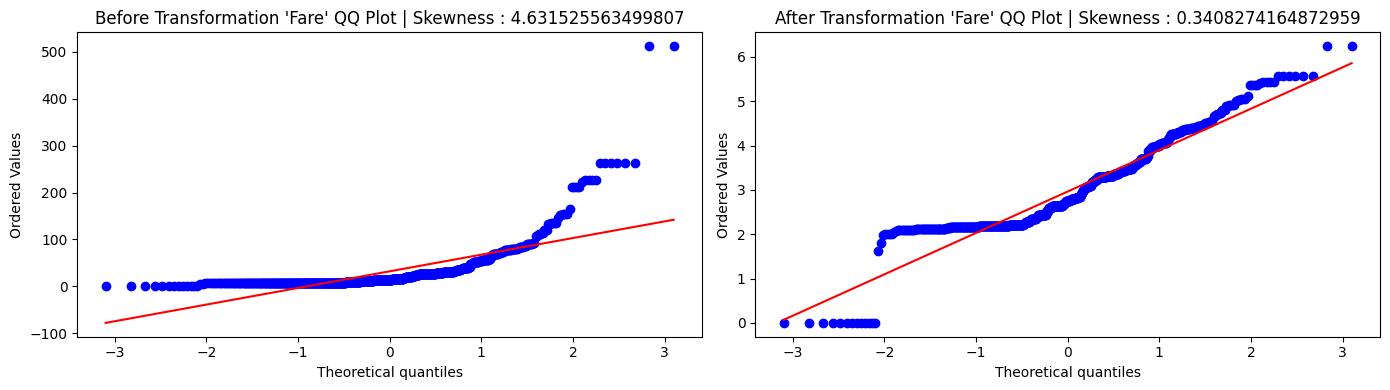

In [29]:
QQ_Plot(X_train, X_train_trans, 'Fare')

### 3.3 Model Evaluation With Transformation

In [60]:
accuracy_lr, accuracy_dt, cross_val_lr, cross_val_dt = Models(X_train_trans, X_test_trans, y_train ,y_test)

print('Logistic Regression Accuracy: ', accuracy_lr, " | Cross val score : ", cross_val_lr)
print('Decision Tree Accuracy: ', accuracy_dt, " | Cross val score : ", cross_val_dt)

Logistic Regression Accuracy:  0.6759776536312849  | Cross val score :  0.6812858926342071
Decision Tree Accuracy:  0.6536312849162011  | Cross val score :  0.6610986267166042


### 3.4 Model Evaluation With Transformation Hybrid Approach

In [31]:
X_train_new = pd.DataFrame({
    'Age': X_train['Age'],
    'Fare': X_train_trans['Fare']
}, index=X_train.index)

X_test_new = pd.DataFrame({
    'Age' : X_test['Age'],
    'Fare' : X_test_trans['Fare']
}, index=X_test.index)

accuracy_lr, accuracy_dt, cross_val_lr, cross_val_dt = Models(X_train_new, X_test_new, y_train ,y_test)

print('Logistic Regression Accuracy: ', accuracy_lr, " | Cross val score : ", cross_val_lr)
print('Decision Tree Accuracy: ', accuracy_dt, " | Cross val score : ", cross_val_dt)

Logistic Regression Accuracy:  0.6759776536312849  | Cross val score :  0.6711735330836454
Decision Tree Accuracy:  0.6424581005586593  | Cross val score :  0.6521348314606741


## 4. Evaluation of Other Transformations

In [ ]:
# Function to apply transformation and evaluate model

def apply_transformation(df, transform):
    
    # Split the dataset into features and target variable
    X = df[['Age', 'Fare']]
    y = df['Survived']
    
    # Apply transformation to the 'Fare' column using ColumnTransformer
    transformer = ColumnTransformer([
        
        ('Transform_Fare', FunctionTransformer(transform), ['Fare'])
        
    ],remainder='passthrough')
    
    # Fit and transform the data
    X_trans = transformer.fit_transform(X)
    
    # ColumnTransformer returns a numpy array, so we need to convert it back to a DataFrame
    X_trans = pd.DataFrame(
        X_trans,
        columns=['Fare', 'Age'],  # Ensure the order of columns matches the transformation
        index = X.index
    )
    
    # Train a Logistic Regression model and evaluate it using cross-validation
    clf = LogisticRegression()
    accuracy = np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10))
    print(f"Accuracy of the model: {accuracy}") 
    
    # Compare QQ plots before and after transformation
    QQ_Plot(X, X_trans, 'Fare')
    



### 4.1 Model Evaluation With Log Transformation

Accuracy of the model: 0.6712609238451936


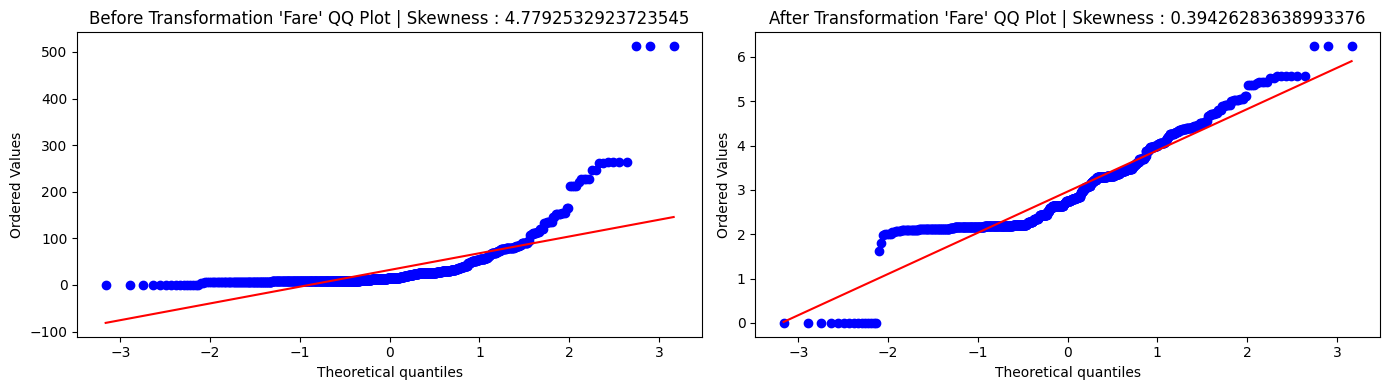

In [51]:
apply_transformation(df,np.log1p) # applying log transformation to 'Fare' column

### 4.2 Model Evaluation With Square Root Transformation

Accuracy of the model: 0.6611485642946316


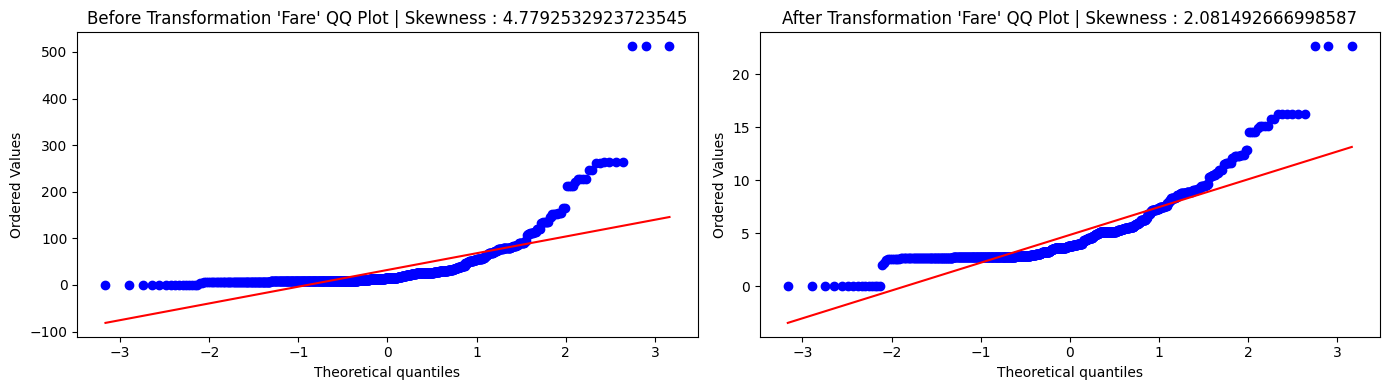

In [48]:
apply_transformation(df, np.sqrt)  # Applying square root transformation

### 4.3 Model Evaluation With Reciprocal Transformation

Accuracy of the model: 0.61729088639201


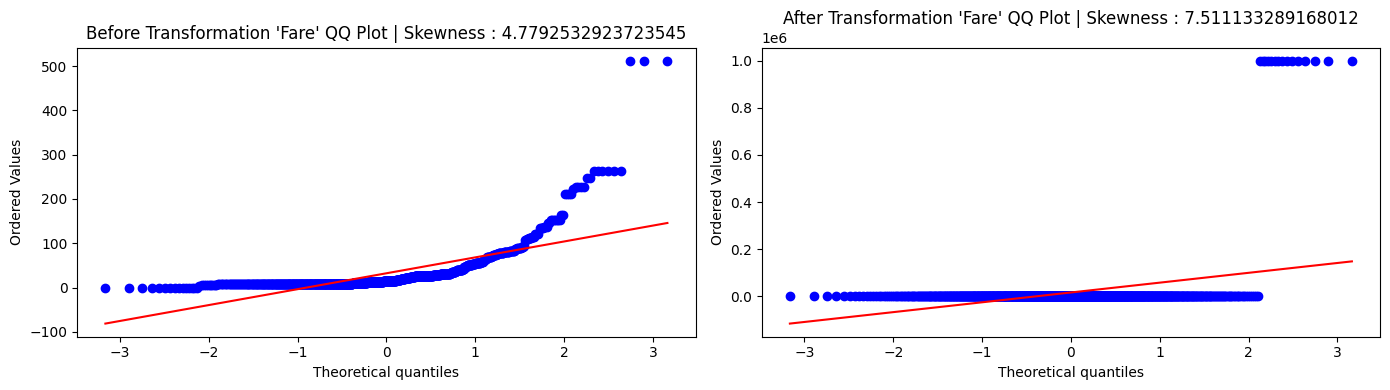

In [ ]:
apply_transformation(df, lambda x: 1/(x+0.000001))  # applying reciprocal transformation with a small constant to avoid division by zero

## Why This Topic is Needed ? 
 
Parametric machine learning models make core mathematical assumptions about the feature space. When these assumptions are violated by raw data distributions, model convergence and predictive validity collapse.

#### 1. Fulfilling the Normality Assumption
Algorithms like **Linear Regression**, **Logistic Regression**, **Linear Discriminant Analysis (LDA)**, and **Neural Networks** assume that numeric features are **normally distributed**. When features are heavily skewed, the model's cost functions (like Mean Squared Error) get dominated by the long tail, resulting in biased coefficients.

#### 2. Resolving Heteroscedasticity (Non-Constant Variance)
A key assumption of linear modeling is homoscedasticity—meaning the residuals (errors) must have constant variance across all levels of the predictor variable. In many raw datasets, the variance increases as the value of the feature increases (e.g., as income increases, spending variance increases). Transformations stabilize this variance across the entire distribution spectrum.

#### 3. Linearizing Non-Linear Relationships
Many real-world phenomena follow power laws, exponential growth patterns, or multiplicative relationships rather than additive ones. Applying a manual transformation (like a log transform on an exponential trend) linearizes the relationship, converting a complex curve into a straight line that a simple linear model can easily fit.


---

## Where It Actually Helps (Practical Applications)

Function transformations provide the greatest utility in domains dealing with heavily right-skewed, positive count, or monetary data.

#### 1. Financial and Monetary Features (Log Transform)
*   **Features:** House prices, income, transaction amounts, stock volumes.
*   **Why it helps:** Money distributions naturally follow power laws (a few individuals/houses have massive values). Transforming these features prevents the highest-priced items from acting as massive lever points that skew regression lines away from the majority of the data.

#### 2. Count and Frequency Features (Square Root Transform)
*   **Features:** Website clicks per hour, traffic accidents per week, calls received by a support center.
*   **Why it helps:** Count data typically follows a **Poisson Distribution**, where the variance is equal to the mean. Applying a square root transformation decouples the variance from the mean, making the distribution approximate a normal curve.

#### 3. Rates, Ratios, and Speeds (Reciprocal Transform)
*   **Features:** Time spent to complete a task, vehicle speed, fuel consumption efficiency.
*   **Why it helps:** It alters the physical perspective of the metric to match the target objective. For example, transforming "kilometers per hour" via reciprocal changes the metric to "hours per kilometer," which scales linearly with the total duration of a delivery trip.

#### 4. Tree-Based Models Exception
*   **Where it does NOT help:** Random Forests, Gradient Boosting Machines (XGBoost, LightGBM).
*   **Why:** Tree-based models split nodes based on order thresholds ($X \leq$ value). Since log, sqrt, and reciprocal transformations preserve the relative order of the data points (monotonic transformations), they do not alter the split decisions or improve tree performance. Focus these transformations strictly on linear models, distance-based metrics (KNN, SVM), and neural networks.
